In [1]:
import pandas as pd
import os

# Aapka sahi rasta (Username HP ke saath)
folder_path = r'C:\Users\HP\Downloads'

try:
    # File ka poora naam check karein
    full_path = os.path.join(folder_path, 'SuperMarket Analysis dataset.csv')
    df = pd.read_csv(full_path)
    print("Success! The dataset has been loaded successfully.")
    display(df.head()) # Behtareen display ke liye
except FileNotFoundError:
 print("File Not Found. Please verify if the file named 'SuperMarket Analysis dataset.csv' exists in your Downloads folder.")

Success! The dataset has been loaded successfully.


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,normal,F,Electronic accessories,15.28,5.0,3.82,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,-7.0,$16.22,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8.0,23.288,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7.0,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [2]:
# Check for missing values (None/NaN)
print("Checking for Trash (Missing Values):")
print(df.isnull().sum())

Checking for Trash (Missing Values):
Invoice ID                  0
Branch                     10
City                       10
Customer type               0
Gender                      0
Product line                0
Unit price                  6
Quantity                   14
Tax 5%                      0
Sales                       0
Date                        0
Time                        0
Payment                     0
cogs                        0
gross margin percentage     0
gross income                0
Rating                     10
dtype: int64


In [3]:
# 1. Numerical values ko mean/median se fill karen
df['Rating'] = df['Rating'].fillna(df['Rating'].mean())
df['Unit price'] = df['Unit price'].fillna(df['Unit price'].mean())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# 2. Categorical values (Branch & City) ko Mode se fill karen
# .mode()[0] isliye likhte hain kyunke mode aik list return karta hai
df['Branch'] = df['Branch'].fillna(df['Branch'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])

# Bonus: Payment method ko bhi fill kar den agar us mein missing values hain
if 'Payment' in df.columns:
    df['Payment'] = df['Payment'].fillna(df['Payment'].mode()[0])

print("Step 2: Missing values for Numerical and Categorical columns have been filled.")

Step 2: Missing values for Numerical and Categorical columns have been filled.


In [4]:
# Fixing gender labels (M -> Male, F -> Female, etc.)
df['Gender'] = df['Gender'].replace({'M': 'Male', 'F': 'Female', 'female': 'Female', 'male': 'Male'})

print("Step 3: Gender labels are now consistent.")

Step 3: Gender labels are now consistent.


In [5]:
# 'Customer type' column mein jo bhi likha ho, usay aik standard format mein lao
# .strip() extra spaces khatam karega, .title() pehla letter capital baqi small kar dega
if 'Customer type' in df.columns:
    df['Customer type'] = df['Customer type'].str.strip().str.title()

print("Step 4: Customer types (Member/Normal) standardized successfully.")

Step 4: Customer types (Member/Normal) standardized successfully.


In [6]:
# 1. Unit Price ke outliers nikalen
df = df[df['Unit price'] < 1000]

# 2. Quantity se zero aur negative values nikalen
# Hum sirf wahi rows rakhenge jahan Quantity 0 se bari ho
df = df[df['Quantity'] > 0]

print("Step 5: Outliers (High Price) and Impossible Values (Zero/Negative Quantity) removed.")

Step 5: Outliers (High Price) and Impossible Values (Zero/Negative Quantity) removed.


In [7]:
# Convert Gender to numbers: Female = 0, Male = 1
df['Gender_n'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Convert Date to proper format
df['Date'] = pd.to_datetime(df['Date'])
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# 1. Encoding 'City' (Lahore, Karachi, etc. to Numbers)
if 'City' in df.columns:
    df['City_n'] = le.fit_transform(df['City'].astype(str))

# 2. Encoding 'Branch' (A, B, C to Numbers)
if 'Branch' in df.columns:
    df['Branch_n'] = le.fit_transform(df['Branch'].astype(str))

print("Encoding Complete: 'City_n' and 'Branch_n' have been added to the dataframe.")

print("Step 6: Data encoding and formatting complete!")

Encoding Complete: 'City_n' and 'Branch_n' have been added to the dataframe.
Step 6: Data encoding and formatting complete!


In [10]:
import pandas as pd

# 1. Pehle ensure karein ke koi null values (NaN) na hon (Sahi column names ke sath)
if 'Tax 5%' in df.columns:
    df['Tax 5%'] = df['Tax 5%'].fillna('0')
if 'Sales' in df.columns:
    df['Sales'] = df['Sales'].fillna('0')

# 2. $ sign aur commas remove karein (clean data mein nahi hain, par safe side ke liye)
if 'Tax 5%' in df.columns:
    df['Tax 5%'] = df['Tax 5%'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
if 'Sales' in df.columns:
    df['Sales'] = df['Sales'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# 3. Numeric mein convert karein
if 'Tax 5%' in df.columns:
    df['Tax 5%'] = pd.to_numeric(df['Tax 5%'], errors='coerce')
if 'Sales' in df.columns:
    df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# 4. Final check: Agar koi invalid value NaN bani ho toh usay 0 kar dein
if 'Tax 5%' in df.columns:
    df['Tax 5%'] = df['Tax 5%'].fillna(0)
if 'Sales' in df.columns:
    df['Sales'] = df['Sales'].fillna(0)

print("Process Complete: Column names fixed, data converted to numeric successfully!")

Process Complete: Column names fixed, data converted to numeric successfully!


In [33]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows found: {duplicate_count}")
# 2. Duplicate rows ko remove karen
# keep='first' ka matlab hai ke pehli entry rakho aur baqi delete kar do
df = df.drop_duplicates(keep='first')

# 3. Reset index (Zaroori hai takay data series barabar rahe)
df = df.reset_index(drop=True)

print("Step 7: Duplicates handled and removed successfully.")

Total Duplicate Rows found: 5
Step 7: Duplicates handled and removed successfully.


In [19]:
# Final check
print("Final Trash Check (Should be all zeros):")
print(df.isnull().sum())

# Save this cleaned file
df.to_csv(r'C:\Users\HP\Downloads\Cleaned_SuperMarket_Data.csv', index=False)
print("Success! Your cleaned dataset is saved in Downloads.")

Final Trash Check (Should be all zeros):
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Gender_n                   0
City_n                     0
Branch_n                   0
dtype: int64
Success! Your cleaned dataset is saved in Downloads.


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features selection (Numeric columns only)
X = df[['Unit price', 'Quantity', 'Gender_n']]
y = df['Sales']

# Data split karna
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model train karna
model = LinearRegression()
model.fit(X_train, y_train)

# Accuracy Score print karna
accuracy = model.score(X_test, y_test)
print(f"Model Training Complete! Final Accuracy Score: {accuracy}")

Model Training Complete! Final Accuracy Score: 0.8871509890690972


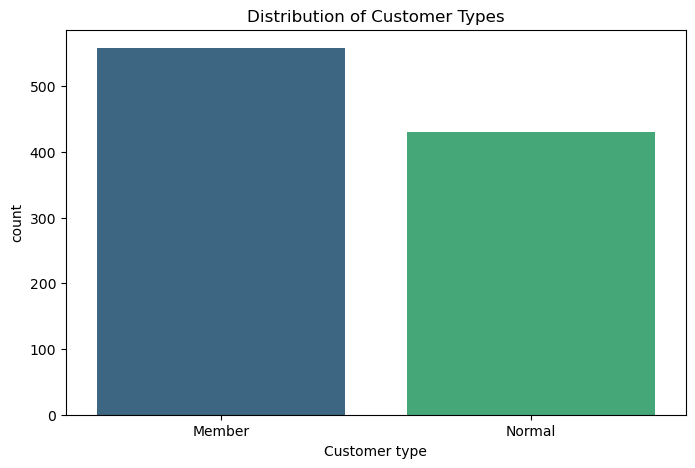

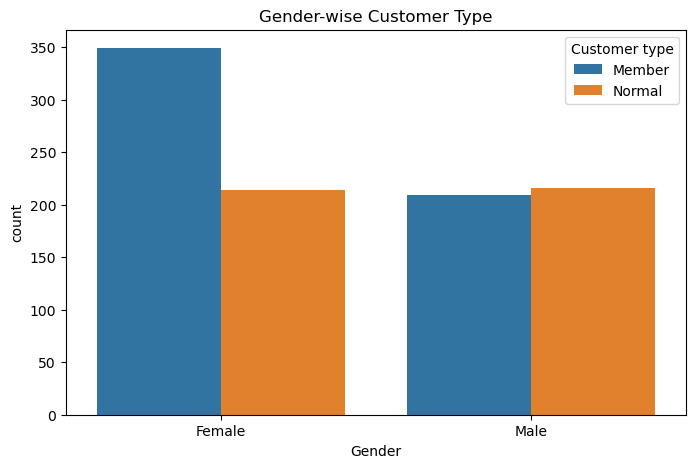

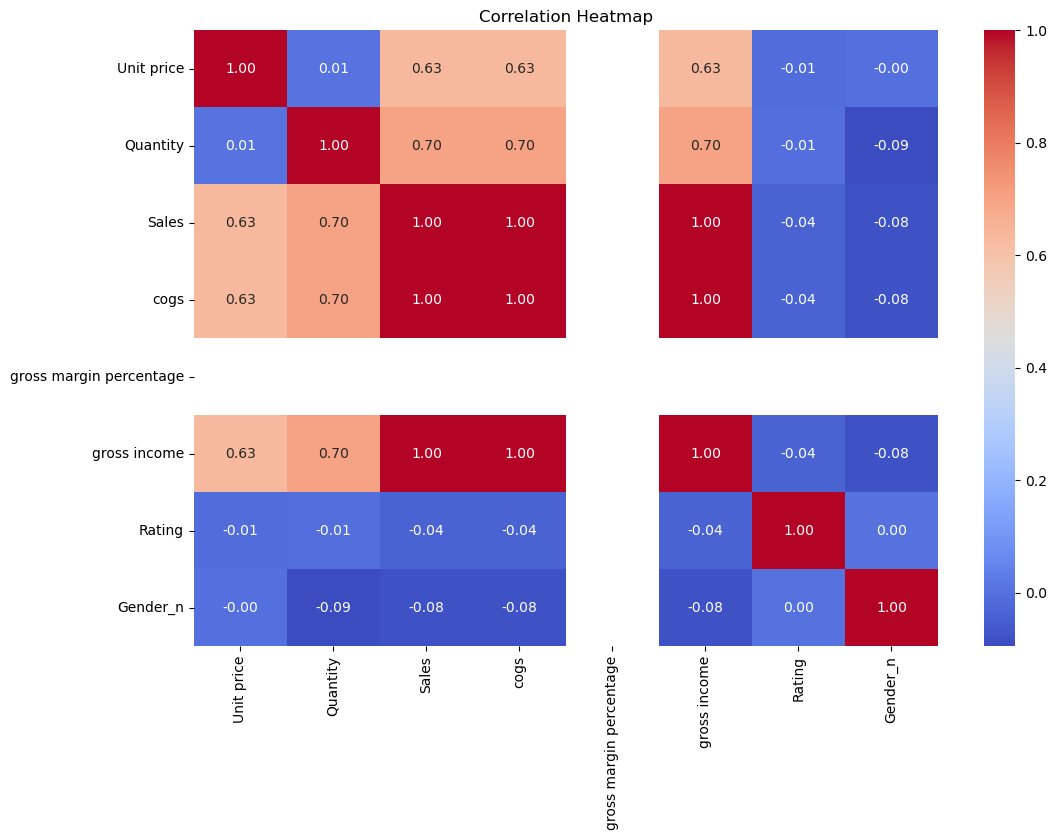

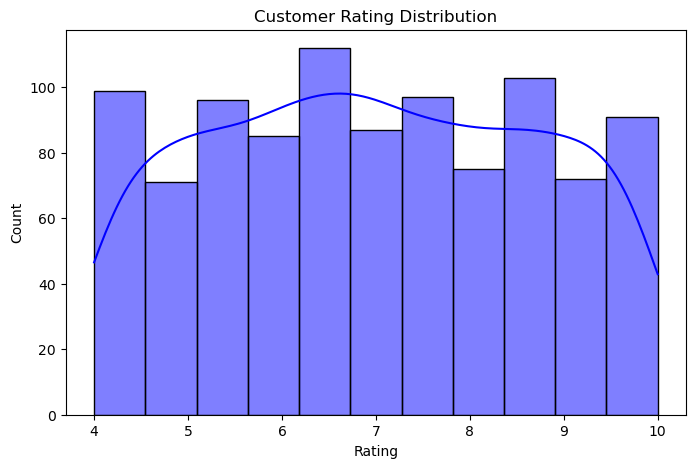

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # <--- Ye line NameError khatam karegi

# 1. Customer Type ki Distribution
plt.figure(figsize=(8, 5))
# Warning fix karne ke liye x ko hi hue mein assign kiya hai
sns.countplot(x='Customer type', data=df, hue='Customer type', palette='viridis', legend=False)
plt.title('Distribution of Customer Types')
plt.show()

# 2. Gender vs Customer Type
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='Customer type', data=df)
plt.title('Gender-wise Customer Type')
plt.show()

# 3. Correlation Matrix
plt.figure(figsize=(12, 8))
# Numeric columns select karne ke liye np.number zaroori hai
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 4. Rating Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Rating'], kde=True, color='blue')
plt.title('Customer Rating Distribution')
plt.show()

In [12]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# 1. Ensure Data is loaded
# (Agar aapka file name different hai toh yahan sahi path likhein)
# df = pd.read_csv('Cleaned_SuperMarket_Data.csv')

# 2. Gender encoding ensure karein
le = LabelEncoder()
if 'Gender' in df.columns:
    df['Gender_n'] = le.fit_transform(df['Gender'].astype(str))

# 3. Features aur Target select karein (Linear Regression ke liye)
X_train_lr = df[['Unit price', 'Quantity', 'Gender_n']]
y_train_lr = df['Sales']

# 4. Model initialize aur train (fit) karein (Ye step NameError khatam karega)
model = LinearRegression()
model.fit(X_train_lr, y_train_lr)
print("Model trained and defined successfully in memory!")

# 5. Ab naye data par check karein (No more NameError!)
sample_df = pd.DataFrame([[50, 5, 1]], columns=['Unit price', 'Quantity', 'Gender_n'])
prediction = model.predict(sample_df)

print(f"Predicted Sales: {prediction[0]:.2f}")

Model trained and defined successfully in memory!
Predicted Sales: 271.53
